## Caption Preprocessing

Di sini, kita preprocess caption pada dataset menggunakan `TextTokenizer` custom yang dibuat di `text_utils.py`. 

In [104]:
import os
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
from PIL import Image
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent.parent 
sys.path.append(str(PROJECT_ROOT))

from src.utility.text_utils import TextTokenizer

DATA_DIR = PROJECT_ROOT / "data" / "2_rnn_image_captioning"
IMAGE_DIR = DATA_DIR / "images"
CAPTIONS_FILE = DATA_DIR / "captions.txt"
VOCAB_FILE = DATA_DIR / "vocab.json"
OUTPUT_SEQ_FILE = DATA_DIR / "processed_captions.npy"
OUTPUT_IMG_FILE = DATA_DIR / "image_ids.npy"

os.makedirs(DATA_DIR, exist_ok=True)

tokenizer = TextTokenizer()

Baca file `data/2_rnn_image_captioning/captions.txt` dan simpan semua captions yang ada pada dictionary `image_to_captions` dengan *key*-nya adalah nama file-nya. 

In [105]:
df = pd.read_csv(CAPTIONS_FILE)

image_to_captions = {}
for _, row in df.iterrows():
   img_id = row['image'].split('.')[0]
   caption = row['caption']
   
   if img_id not in image_to_captions:
      image_to_captions[img_id] = []
   image_to_captions[img_id].append(caption)

print(f"Loaded {len(image_to_captions)} unique images.")
print(f"Loaded {len(df)} total captions.")

Loaded 8091 unique images.
Loaded 40455 total captions.


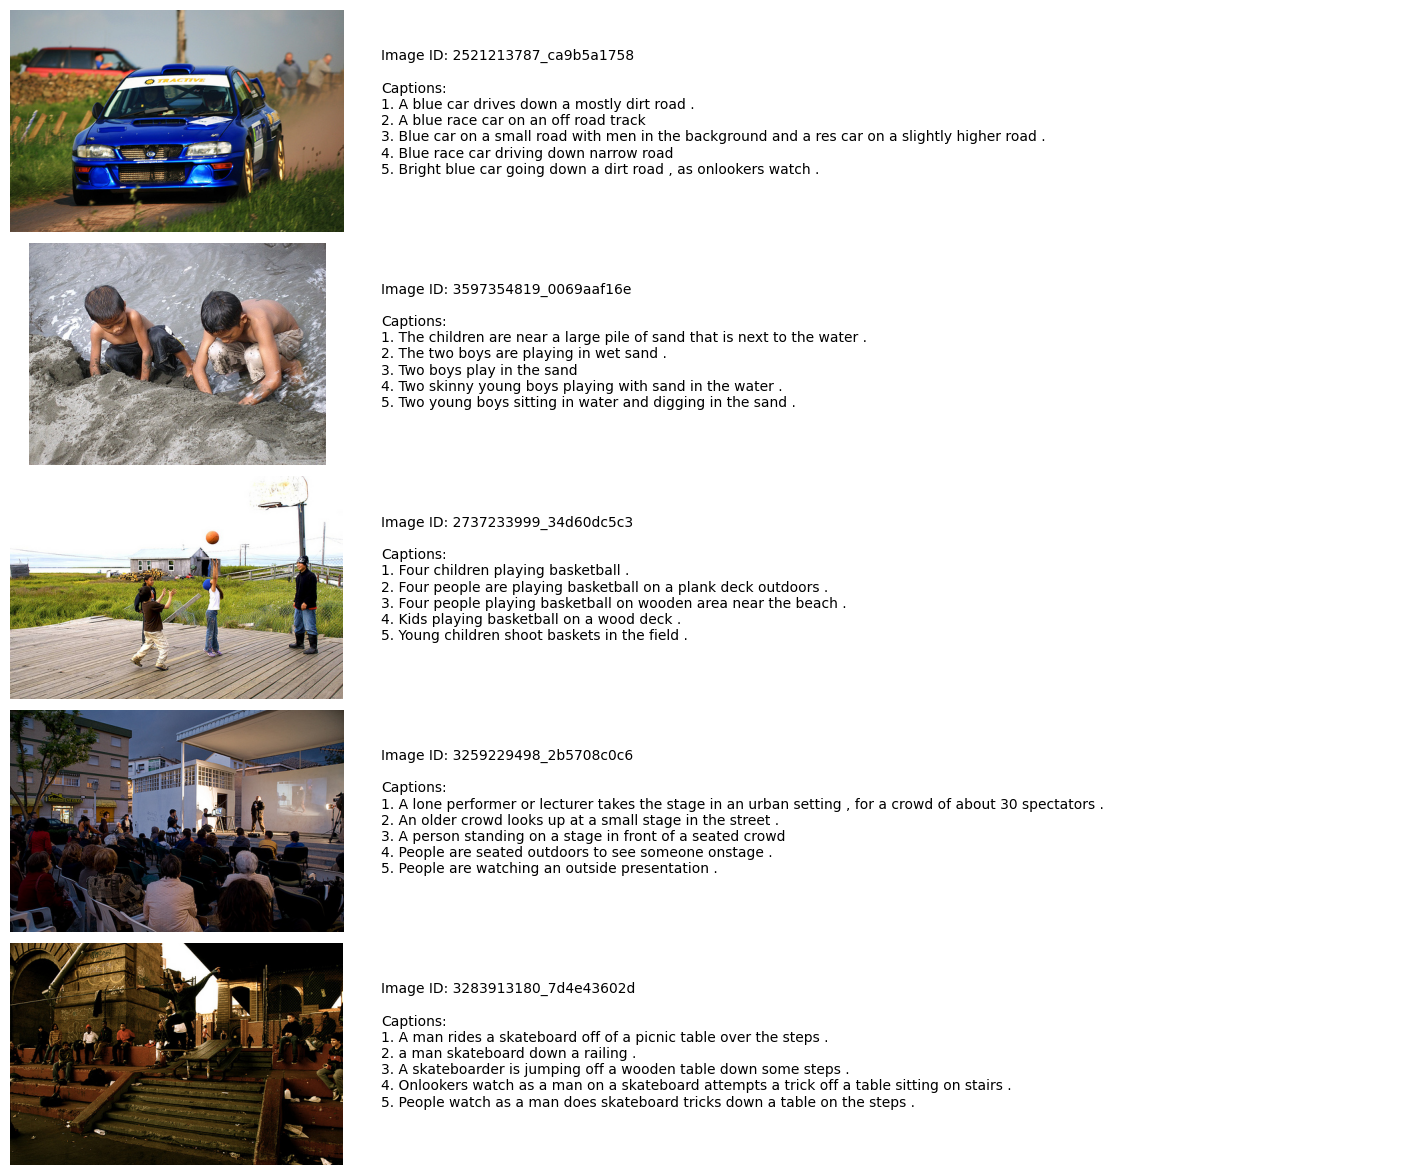

In [106]:
def visualize(data, num_of_images=5):
   random_keys = random.sample(list(data.keys()), min(num_of_images, len(data)))
   
   fig, axes = plt.subplots(len(random_keys), 2, 
                           figsize=(18, 3 * len(random_keys)), 
                           gridspec_kw={'width_ratios': [1, 3]})
   fig.patch.set_alpha(0.0)

   if len(random_keys) == 1:
      axes = [axes]

   for idx, key in enumerate(random_keys):
      ax_img, ax_txt = axes[idx]
      captions = data[key]
      img_path = IMAGE_DIR / f"{key}.jpg"
      
      try:
         img = Image.open(img_path)
         ax_img.imshow(img)
      except FileNotFoundError:
         ax_img.text(0.5, 0.5, 'Image Not Found', ha='center', va='center')
      
      ax_img.axis('off') 
      ax_txt.axis('off')
      
      caption_text = f"Image ID: {key}\n\nCaptions:\n"
      for i, cap in enumerate(captions, 1):
         caption_text += f"{i}. {cap}\n"
      
      ax_txt.text(0.0, 0.5, caption_text, fontsize=10, va='center', ha='left', wrap=True)

   plt.subplots_adjust(hspace=0.05, wspace=0.05) 
   plt.show()

visualize(image_to_captions)

Bangun *vocabulary* menggunakan `.build_vocab()` yang disimpan menjadi dictionary sebagai atribut `tokenizer`. 

In [107]:
all_captions = df['caption'].tolist()
tokenizer.build_vocab(all_captions)

print(f"Built vocabulary. Total unique words: {tokenizer.vocab_size}")

Built vocabulary. Total unique words: 8832


Sekarang, kita konversikan teks caption menjadi *token sequence* dengan `encode()` dan diberikan pad dengan `pad_sequence()`. Hasilnya disimpan pada array `padded_sequences` dengan nama gambar yang berkorespondensi satu-satu dengannya disimpan di array `ordered_image_ids`. 

In [108]:
encoded_sequences = []
ordered_image_ids = []

for img_id, captions in image_to_captions.items():
   for caption in captions:
      seq = tokenizer.encode(caption)
      encoded_sequences.append(seq)
      ordered_image_ids.append(img_id)

max_length = max([len(seq) for seq in encoded_sequences])
padded_sequences = tokenizer.pad_sequence(encoded_sequences, max_length=max_length)

print(f"Total encoded sequences: {len(padded_sequences)}")
print(f"Maximum sequence length: {max_length}")

Total encoded sequences: 40455
Maximum sequence length: 38


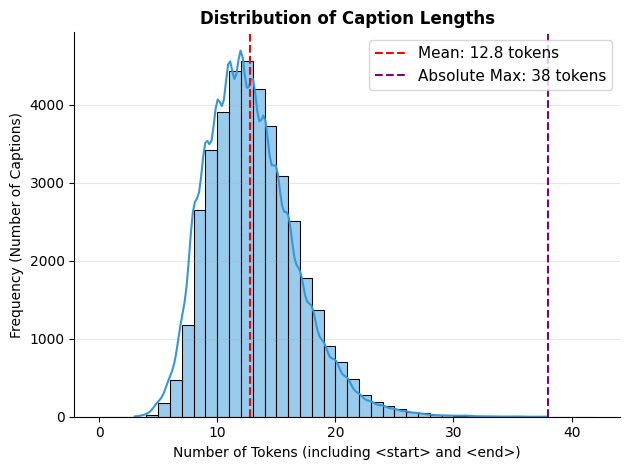

In [109]:
sequence_lengths = [len(seq) for seq in encoded_sequences]

mean_len = np.mean(sequence_lengths)
max_len = np.max(sequence_lengths)

sns.histplot(sequence_lengths, bins=range(0, max_len + 5), kde=True, color='#3498db', edgecolor='black')

plt.axvline(mean_len.item(), color='red', linestyle='--', label=f'Mean: {mean_len:.1f} tokens')
plt.axvline(max_len, color='purple', linestyle='--', label=f'Absolute Max: {max_len} tokens')

plt.title('Distribution of Caption Lengths', fontweight='bold')
plt.xlabel('Number of Tokens (including <start> and <end>)')
plt.ylabel('Frequency (Number of Captions)')
plt.legend(fontsize=11)
plt.grid(axis='y', alpha=0.3)

sns.despine()

plt.tight_layout()
plt.show()

Hasil pre-processing disimpan pada disk secara langsung untuk memudahkan: 
- `vocab.json`: menyimpan *vocabulary* semua kata yang ada
- `processed_captions.npy`: menyimpan semua representasi *token sequence* dari caption
- `image_ids.npy`: menyimpan nama file gambar yang berkorespondensi dengan caption
- `config.json`: menyimpan `max_length` dan `vocab_size` untuk memudahkan *look-up*

In [110]:
tokenizer.save_vocab(VOCAB_FILE)
np.save(OUTPUT_SEQ_FILE, padded_sequences)
np.save(OUTPUT_IMG_FILE, np.array(ordered_image_ids))

config = {"max_length": max_length, "vocab_size": tokenizer.vocab_size}
with open(DATA_DIR / "config.json", "w") as f:
   json.dump(config, f)

print(f"Preprocessing complete! All artifacts saved to:\n{DATA_DIR}")

Preprocessing complete! All artifacts saved to:
D:\ITB\Semester 6\ML\Tugas Besar 2\data\2_rnn_image_captioning
